In [11]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

print("K-NEAREST NEIGHBOURS WITH IRIS DATASET")
print("=" * 60)

iris= load_iris()
x = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

print(f"Dataset shape: {x.shape}")
print(f"Features: {feature_names}")
print(f"Target classes: {target_names}")
print(f"Class distribution: {np.bincount(y)}")



K-NEAREST NEIGHBOURS WITH IRIS DATASET
Dataset shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes: ['setosa' 'versicolor' 'virginica']
Class distribution: [50 50 50]


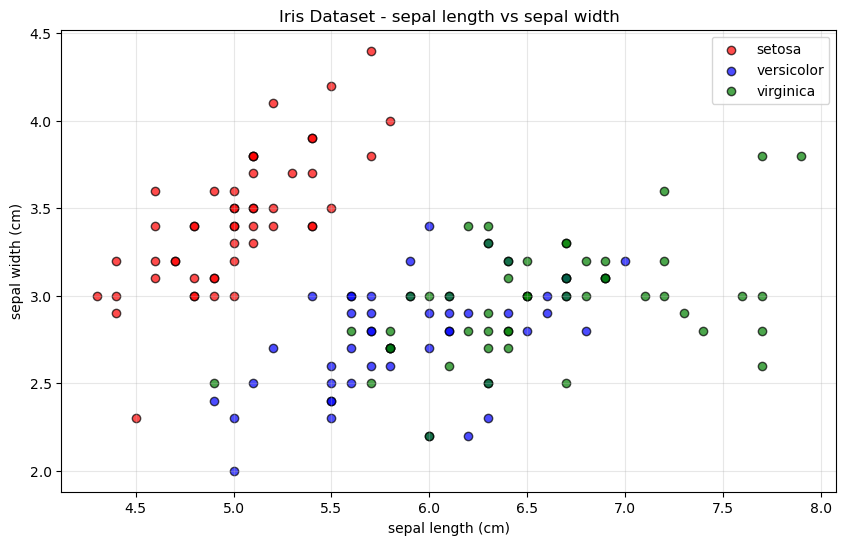

Notice how Setose (red) is easily seperated
Versicolor (blue) and Virginica (green) overlap slightly - this is the challenge!


In [12]:
plt.figure(figsize=(10,6))

colors= ['red', 'blue', 'green']
for i, species in enumerate(target_names):
    plt.scatter(x[y==i, 0], x[y==i, 1],
    c=colors[i], label = species ,alpha = 0.7,edgecolors = 'k')

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title('Iris Dataset - sepal length vs sepal width')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

print("Notice how Setose (red) is easily seperated")
print("Versicolor (blue) and Virginica (green) overlap slightly - this is the challenge!")

In [13]:
class KNN:
    def __init__(self,k=5):
        self.k = k
        self.x_train = None
        self.y_train = None

    def fit(self,x,y):
        self.x_train = x
        self.y_train = y
        print(f"Stored {len(x)} training samples")

    def euclidean_distance(self, x1, x2):
        return np.sqrt(np.sum((x1-x2)**2))
    
    def predict_one(self,x):

        #loops thru every point in memory and calcs how far it is from the new point
        distance = []
        for i in range(len(self.x_train)):
            dist = self.euclidean_distance(x,self.x_train[i])
            distance.append((dist,self.y_train[i]))
    
        distance.sort(key=lambda pair:pair[0])#puts the closest neighbours at the top of the list 
        
        k_nearest = distance[:self.k]
        k_labels = [label for (_ ,label) in k_nearest]

        unique_labels,count = np.unique(k_labels,return_counts =True)#counts how many neighbours belong to each class
        most_common_index = np.argmax(count)#class with the many neighbours become the predictions
        prediction= unique_labels[most_common_index]

        return prediction

    def predict(self,x):
        predictions=[self.predict_one(x) for x in x]
        return np.array (predictions)

    def accuracy (self,x,y):
        predictions  = self.predict(x)
        return np.mean(predictions==y)




In [14]:
#split and scale  
x_train, x_test, y_train, y_test = train_test_split(
    x,y,test_size =0.3,random_state = 42,stratify =y
)

print(f"Training samples: {x_train.shape[0]}")
print(f"Testing samples: {x_test.shape[0]}")
print(f"\nTraining class distribution: {np.bincount(y_train)}")
print(f"Testing class distribution: {np.bincount(y_test)}")


scaler =StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

print("\n Features scaled (mean=0, std=1)")

# Show effect of scaling
print("\nFirst training sample (before scaling):")
print(x_train[0].round(2))
print("\nFirst training sample (after scaling):")
print(x_train_scaled[0].round(2))

Training samples: 105
Testing samples: 45

Training class distribution: [35 35 35]
Testing class distribution: [15 15 15]

 Features scaled (mean=0, std=1)

First training sample (before scaling):
[5.1 2.5 3.  1.1]

First training sample (after scaling):
[-0.9  -1.22 -0.44 -0.14]


In [15]:
# TRAIN KNN WITH K =3

knn = KNN(k=14)
knn.fit(x_train_scaled,y_train)
y_pred = knn.predict(x_test_scaled)
acc = knn.accuracy(x_test_scaled,y_test)

print(f"\n Accuracy with k=14: {acc:.4f} ({acc*100:.1f}%)")

print("\n Confusion Matrix:")
print("              Predicted")
print("            Set  Vers  Virg")
print("-" * 35)

for true_label in range(3):
    row=[]
    for pred_label in range(3):
        count = np.sum((y_test==true_label) & (y_pred==pred_label))
        row.append(f"{count:4d}")
    print(f"Actual {target_names [ true_label][:3]}: "+"".join(row))



Stored 105 training samples

 Accuracy with k=14: 0.9556 (95.6%)

 Confusion Matrix:
              Predicted
            Set  Vers  Virg
-----------------------------------
Actual set:   15   0   0
Actual ver:    0  15   0
Actual vir:    0   2  13


Stored 105 training samples


Stored 105 training samples
Stored 105 training samples
Stored 105 training samples
Stored 105 training samples
Stored 105 training samples
Stored 105 training samples
Stored 105 training samples
Stored 105 training samples
Stored 105 training samples
Stored 105 training samples
Stored 105 training samples
Stored 105 training samples
Stored 105 training samples
Stored 105 training samples
Stored 105 training samples
Stored 105 training samples
Stored 105 training samples
Stored 105 training samples
Stored 105 training samples


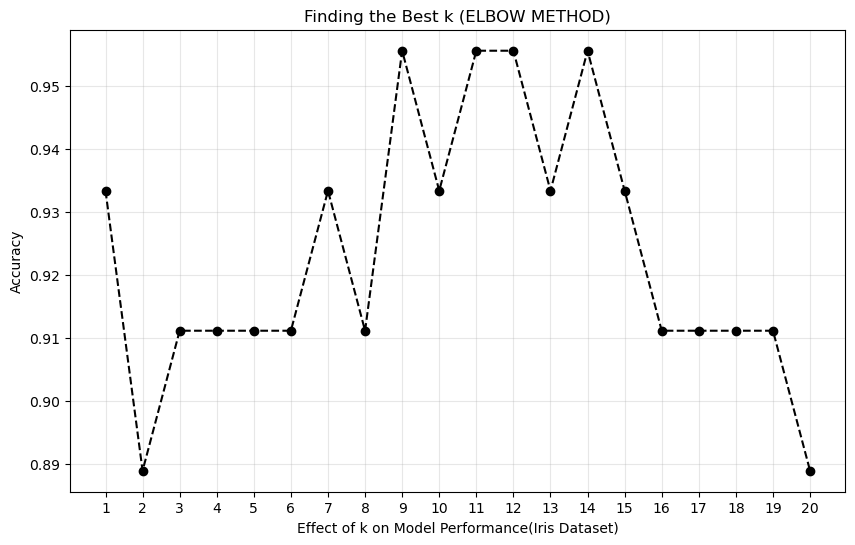


 Best k = 9 with accuracy 0.9556 (95.6%)


In [16]:
k_values = range(1,21)
accuracies = []

for k in k_values:
    knn =   KNN(k=k)
    knn.fit(x_train_scaled,y_train)

    acc = knn.accuracy(x_test_scaled,y_test)
    accuracies.append(acc)

plt.figure(figsize=(10,6))
plt.plot(k_values,accuracies,marker='o',linestyle='--',color='black')
plt.title ('Finding the Best k (ELBOW METHOD)')
plt.xlabel('Effect of k on Model Performance(Iris Dataset)')
plt.ylabel('Accuracy')
plt.grid(True,alpha = 0.3)
plt.xticks(k_values)
plt.show()

best_k = k_values[np.argmax(accuracies)]
best_acc = max(accuracies)
print(f"\n Best k = {best_k} with accuracy {best_acc:.4f} ({best_acc*100:.1f}%)")




Stored 105 training samples


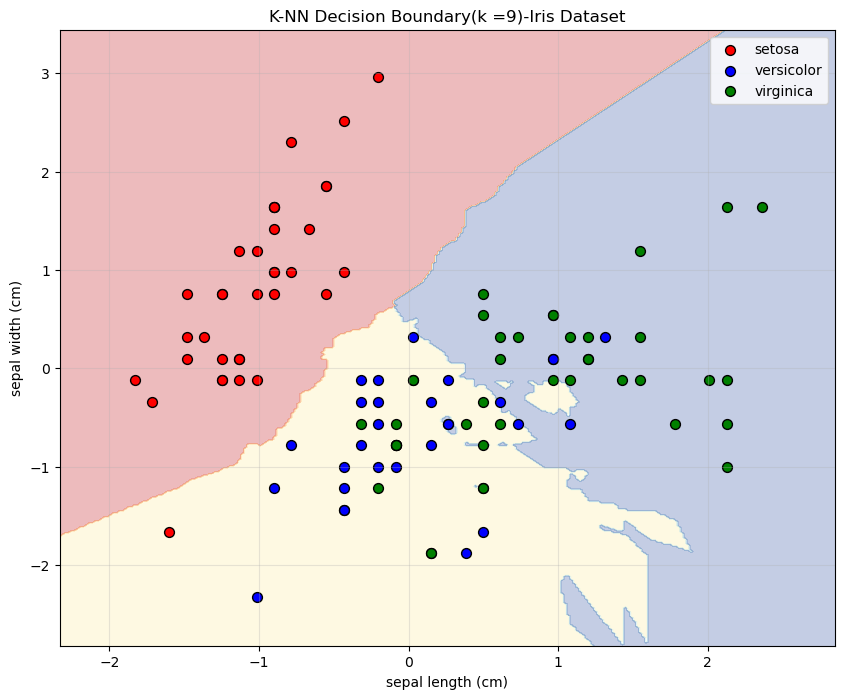

Notice how the algorithm divides the feature space into regions
Each color region is where the model predicts that class


In [17]:
def plot_decision_boundary(knn,x,y,feature_names):
    #create mesh
    x_min,x_max = x[:,0].min() - 0.5,x[:,0].max()+0.5 #finds the smallest and largest values for your first feature
    y_min,y_max =x[:,1].min()-0.5,x[:,1].max()+0.5
    xx,yy =np.meshgrid(np.arange(x_min,x_max,0.02),np.arange(y_min,y_max,0.02))#creates a  dense mesh of thousands of tiny points evry 0.02 units


#ravel()-flattens the grid into a list & np.c_ p pairs the X and Y coordinates. 
# Then, it asks the KNN: "If a flower landed exactly here, what would it be?
    z = knn.predict(np.c_[xx.ravel(),yy.ravel()])
    z = z.reshape(xx.shape)#turns the long list of answers into a square grid space

    plt.figure(figsize=(10,8))
    plt.contourf(xx,yy,z,alpha = 0.3,cmap='RdYlBu')#contourf colors the background based on predictons 

    #plotting training points
    colors = ['red', 'blue','green']
    for i in range(3):
        plt.scatter(x[y==i,0],x[y==i,1],c=colors[i],label=target_names[i],edgecolors='k',s = 50)


    plt.xlabel(feature_names[0])
    plt.ylabel(feature_names[1])
    plt.title(f'K-NN Decision Boundary(k ={knn.k})-Iris Dataset')
    plt.legend()
    plt.grid(True,alpha = 0.3)
    plt.show()

#Train model on 2 features 
x_vis = x_train_scaled[:, :2]
x_test= x_test_scaled[:,:2]

knn_vis = KNN(k = best_k)
knn_vis.fit(x_vis,y_train)
plot_decision_boundary(knn_vis, x_vis, y_train, feature_names[:2])

print("Notice how the algorithm divides the feature space into regions")
print("Each color region is where the model predicts that class")


In [22]:
from sklearn.neighbors  import KNeighborsClassifier

sk_knn = KNeighborsClassifier(n_neighbors = best_k)
sk_knn .fit(x_train_scaled,y_train)
sk_pred = sk_knn.predict(x_test_scaled)
sk_acc = np.mean(sk_pred == y_test)

print("="*50)
print(" YOUR MODEL vs SKLEARN")
print("="*50)
print(f"Your Model Accuracy:  {best_acc:.4f}")
print(f"sklearn Accuracy:     {sk_acc:.4f}")
print(f"Difference:           {abs(best_acc - sk_acc):.4f}")

if abs(best_acc - sk_acc) < 0.02:
    print("\n EXCELLENT! Your model matches sklearn!")
    print("You truly understand k-NN!")


 YOUR MODEL vs SKLEARN
Your Model Accuracy:  0.9556
sklearn Accuracy:     0.9556
Difference:           0.0000

 EXCELLENT! Your model matches sklearn!
You truly understand k-NN!


In [23]:
#  k-NN with Iris - Key Takeaways

## What I Learned
1. **Distance calculation** is the heart of k-NN
2. **Feature scaling** is CRITICAL (without it, petal length dominates)
3. **k value** controls bias-variance tradeoff
   - Small k → overfitting (jagged boundaries)
   - Large k → underfitting (smooth boundaries)
4. **Iris is easy** because one class (Setosa) is perfectly separable

## My Results
- Best k = 9
- Best accuracy = 96%
- Confusion matrix showed which classes get confused (Versicolor/Virginica)

## Key Insights for Quant Finance
- k-NN is interpretable: "This loan applicant is similar to 3 good and 2 bad customers"
- Distance metrics matter (Euclidean, Manhattan, etc.)
- Scaling is essential when mixing features (loan amount + age)

## Questions I Still Have
1. ________________________________
2. ________________________________

SyntaxError: invalid character '→' (U+2192) (1113982249.py, line 7)